# 03. Sparkov Baseline Fraud Models

This notebook establishes the first predictive baselines for the Sparkov fraud-detection project.

The purpose is **not** to build the final model. Instead, it creates a clean reference point using only information available in the current transaction.

Later notebooks will add past-only behavioral features, imbalance strategies, probability calibration, cost-sensitive decision rules, alert-capacity constraints, and temporal-drift analysis.

## Main Question

> How well can we detect future fraud using only current-transaction information, before adding historical behavioral features?

## Models

1. **Dummy Classifier** — no-skill reference
2. **Logistic Regression** — simple linear baseline
3. **LightGBM** — nonlinear tree-based baseline

## Leakage Rule

All preprocessing is fitted using the **Train** period only. The **Validation** period is used for development evaluation. The **Test** period remains locked and is not evaluated here.

## 1. Import Libraries and Create Output Folders

`/kaggle/working/` is Kaggle's writable output directory. Metrics and figures created here can later be downloaded and committed to GitHub.

In [20]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load the Sparkov Dataset

This notebook runs independently from Notebook 02. It reloads the raw Sparkov CSV and recreates the same split rules.

The project uses:

`/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv`

In [21]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
display(df.head())

Raw shape: (1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


## 3. Basic Cleaning

The CSV may contain an `Unnamed: 0` index column. It is removed because it is not a real transaction feature.

The transaction timestamp and date of birth are converted to datetime values. The synthetic merchant prefix `fraud_` is removed to avoid confusing a naming convention with a predictive label.

In [22]:
unnamed_cols = [
    col for col in df.columns
    if col.lower().startswith("unnamed")
]

df = df.drop(columns=unnamed_cols, errors="ignore")

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"], errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"], errors="coerce"
)

df["merchant_clean"] = (
    df["merchant"]
    .str.replace(r"^fraud_", "", regex=True)
)

print("Shape after cleanup:", df.shape)
print("Invalid timestamps:", df["trans_date_trans_time"].isna().sum())
print("Invalid DOB values:", df["dob"].isna().sum())

Shape after cleanup: (1296675, 24)
Invalid timestamps: 0
Invalid DOB values: 0


## 4. Sort Transactions Chronologically

Fraud detection is a future-prediction problem. We sort by `unix_time`, using `trans_num` only as a deterministic tie-breaker.

In [23]:
df = (
    df.sort_values(["unix_time", "trans_num"])
      .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Chronological ordering check passed.")
print("Period:", df["trans_date_trans_time"].min(), "to", df["trans_date_trans_time"].max())
print("Transactions:", len(df))
print("Frauds:", int(df["is_fraud"].sum()))
print("Fraud rate:", df["is_fraud"].mean())

Chronological ordering check passed.
Period: 2019-01-01 00:00:18 to 2020-06-21 12:13:37
Transactions: 1296675
Frauds: 7506
Fraud rate: 0.005788651743883394


## 5. Create Current-Transaction Features

This baseline intentionally uses only information available in the current transaction.

We create time, age, and geographic-distance features. No card history, merchant history, rolling averages, or future information is used.

In [24]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 6371 * 2 * np.arcsin(np.sqrt(a))


df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
)

df["distance_home_to_merchant_km"] = haversine_km(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

display(df[[
    "amt", "hour", "day_of_week", "is_weekend",
    "age", "distance_home_to_merchant_km"
]].head())

,amt,hour,day_of_week,is_weekend,age,distance_home_to_merchant_km
0,4.97,0,1,0,30.814511,78.597568
1,107.23,0,1,0,40.531143,30.212176
2,220.11,0,1,0,56.950034,108.206083
3,45.00,0,1,0,51.969884,95.673231
4,41.96,0,1,0,32.763860,77.556744


## 6. Recreate the Fixed Chronological Split

We reuse the Notebook 02 design:

- Train: first 60%
- Calibration: next 15%
- Validation: next 10%
- Test: final 15%
- 24-hour total purge window around each boundary

Calibration is kept for later notebooks. Test is created only to keep the experiment consistent and remains untouched here.

In [25]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

PURGE_HOURS = 24
HALF_PURGE_SECONDS = int((PURGE_HOURS / 2) * 3600)

n = len(df)

train_boundary_idx = int(n * TRAIN_RATIO)
calibration_boundary_idx = int(n * (TRAIN_RATIO + CALIBRATION_RATIO))
validation_boundary_idx = int(n * (TRAIN_RATIO + CALIBRATION_RATIO + VALIDATION_RATIO))

train_boundary = int(df.iloc[train_boundary_idx]["unix_time"])
calibration_boundary = int(df.iloc[calibration_boundary_idx]["unix_time"])
validation_boundary = int(df.iloc[validation_boundary_idx]["unix_time"])

train = df[
    df["unix_time"] < train_boundary - HALF_PURGE_SECONDS
].copy()

calibration = df[
    (df["unix_time"] > train_boundary + HALF_PURGE_SECONDS)
    & (df["unix_time"] < calibration_boundary - HALF_PURGE_SECONDS)
].copy()

validation = df[
    (df["unix_time"] > calibration_boundary + HALF_PURGE_SECONDS)
    & (df["unix_time"] < validation_boundary - HALF_PURGE_SECONDS)
].copy()

test = df[
    df["unix_time"] > validation_boundary + HALF_PURGE_SECONDS
].copy()

assert train["unix_time"].max() < calibration["unix_time"].min()
assert calibration["unix_time"].max() < validation["unix_time"].min()
assert validation["unix_time"].max() < test["unix_time"].min()

print({
    "train": len(train),
    "calibration": len(calibration),
    "validation": len(validation),
    "test": len(test),
})

{'train': 777050, 'calibration': 192249, 'validation': 128128, 'test': 193574}


### Split Sanity Check

Validation and Test keep their natural fraud prevalence. We do not artificially rebalance them.

In [26]:
split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train),
        "frauds": int(train["is_fraud"].sum()),
        "fraud_rate": train["is_fraud"].mean(),
        "start": train["trans_date_trans_time"].min(),
        "end": train["trans_date_trans_time"].max(),
    },
    {
        "split": "calibration",
        "rows": len(calibration),
        "frauds": int(calibration["is_fraud"].sum()),
        "fraud_rate": calibration["is_fraud"].mean(),
        "start": calibration["trans_date_trans_time"].min(),
        "end": calibration["trans_date_trans_time"].max(),
    },
    {
        "split": "validation",
        "rows": len(validation),
        "frauds": int(validation["is_fraud"].sum()),
        "fraud_rate": validation["is_fraud"].mean(),
        "start": validation["trans_date_trans_time"].min(),
        "end": validation["trans_date_trans_time"].max(),
    },
    {
        "split": "test",
        "rows": len(test),
        "frauds": int(test["is_fraud"].sum()),
        "fraud_rate": test["is_fraud"].mean(),
        "start": test["trans_date_trans_time"].min(),
        "end": test["trans_date_trans_time"].max(),
    },
])

display(split_summary)
assert (split_summary["frauds"] > 0).all()

,split,rows,frauds,fraud_rate,start,end
0,train,777050,4584,0.005899,2019-01-01 00:00:18,2019-11-29 07:35:17
1,calibration,192249,919,0.004780,2019-11-30 07:37:20,2020-01-28 03:04:27
2,validation,128128,843,0.006579,2020-01-29 03:06:41,2020-04-03 05:52:32
3,test,193574,1126,0.005817,2020-04-04 05:55:26,2020-06-21 12:13:37


## 7. Define the Baseline Feature Set

### Numerical
`amt`, `city_pop`, `age`, geographic distance, and time features.

### Categorical
`category`, `merchant_clean`, `state`, and `job`.

### Intentionally excluded

- `is_fraud`: target
- `trans_num`: identifier
- `cc_num`: raw card identifier
- `first`, `last`, `street`, `zip`: identity/memorization fields
- any future or historical aggregate

`cc_num` will later be used to build past-only behavior, but not as a raw numeric predictor.

In [27]:
numeric_features = [
    "amt",
    "city_pop",
    "age",
    "distance_home_to_merchant_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

categorical_features = [
    "category",
    "merchant_clean",
    "state",
    "job",
]

feature_cols = numeric_features + categorical_features
TARGET = "is_fraud"

X_train = train[feature_cols]
y_train = train[TARGET]
X_val = validation[feature_cols]
y_val = validation[TARGET]
validation_amount = validation["amt"].to_numpy()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total input columns:", len(feature_cols))

Numerical features: 11
Categorical features: 4
Total input columns: 15


## 8. Define Evaluation Metrics

Because fraud is rare, accuracy is not used as a primary metric.

### Ranking
- **PR-AUC** — primary ranking metric
- ROC-AUC — secondary ranking metric

### Threshold-based reference metrics
- Precision
- Recall
- F1
- Alert rate

### Probability quality
- Brier Score
- Log Loss

### Amount-weighted metric
- Fraud Amount Recall

The threshold of 0.5 is only a temporary reference. Cost-sensitive threshold selection comes later.

In [28]:
def fraud_amount_recall(y_true, pred, amount):
    y = np.asarray(y_true)
    pred = np.asarray(pred)
    amount = np.asarray(amount)

    total_fraud_amount = amount[y == 1].sum()

    if total_fraud_amount == 0:
        return np.nan

    detected_fraud_amount = amount[(y == 1) & (pred == 1)].sum()

    return detected_fraud_amount / total_fraud_amount


def evaluate_model(model_name, y_true, proba, amount, threshold=0.5):
    proba = np.asarray(proba)
    pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "brier": brier_score_loss(y_true, proba),
        "log_loss": log_loss(
            y_true,
            np.clip(proba, 1e-8, 1 - 1e-8)
        ),
        "alert_rate": pred.mean(),
        "fraud_amount_recall": fraud_amount_recall(
            y_true,
            pred,
            amount
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

## 9. Dummy Classifier

The Dummy Classifier is a no-skill reference. It predicts using only the fraud prevalence learned from Train.

In [29]:
dummy = DummyClassifier(strategy="prior")

dummy.fit(
    np.zeros((len(y_train), 1)),
    y_train
)

dummy_proba = dummy.predict_proba(
    np.zeros((len(y_val), 1))
)[:, 1]

dummy_metrics = evaluate_model(
    "Dummy",
    y_val,
    dummy_proba,
    validation_amount
)

dummy_metrics

{'model': 'Dummy',
 'threshold': 0.5,
 'roc_auc': np.float64(0.5),
 'pr_auc': np.float64(0.006579358141858142),
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'brier': np.float64(0.006536532756762005),
 'log_loss': 0.03964917806796323,
 'alert_rate': np.float64(0.0),
 'fraud_amount_recall': np.float64(0.0),
 'true_negative': 127285,
 'false_positive': 0,
 'false_negative': 843,
 'true_positive': 0}

## 10. Logistic Regression

Logistic Regression is a simple linear baseline.

### Leakage-safe preprocessing

All preprocessing is fitted on Train only.

Numerical variables use median imputation and standardization. Categorical variables use most-frequent imputation and one-hot encoding.

`class_weight="balanced"` is used here only as a baseline configuration. A dedicated imbalance comparison is performed in Notebook 05.

In [30]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20
        )
    ),
])

logistic_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="saga",
            random_state=SEED,
            n_jobs=-1
        )
    ),
])

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [31]:
logistic_model.fit(X_train, y_train)

logistic_proba = logistic_model.predict_proba(X_val)[:, 1]

logistic_metrics = evaluate_model(
    "Logistic Regression",
    y_val,
    logistic_proba,
    validation_amount
)

logistic_metrics

{'model': 'Logistic Regression',
 'threshold': 0.5,
 'roc_auc': np.float64(0.8677982564136831),
 'pr_auc': np.float64(0.1250645159028418),
 'precision': 0.042074212078869744,
 'recall': 0.6429418742586003,
 'f1': 0.0789799635701275,
 'brier': np.float64(0.06915803685352644),
 'log_loss': 0.23747424461451355,
 'alert_rate': np.float64(0.10054008491508491),
 'fraud_amount_recall': np.float64(0.8589087434998759),
 'true_negative': 114945,
 'false_positive': 12340,
 'false_negative': 301,
 'true_positive': 542}

### Interpretation

Focus first on PR-AUC, Recall, Precision, and Brier Score. The 0.5 threshold is only a reference point and should not be treated as an operational fraud rule.

## 11. LightGBM

LightGBM can learn nonlinear effects and interactions that Logistic Regression cannot represent directly.

For categorical variables we use an `OrdinalEncoder` fitted on Train. The resulting integers are internal category codes, not meaningful numeric quantities.

In [32]:
lgbm_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

lgbm_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
])

lgbm_preprocessor = ColumnTransformer([
    ("numeric", lgbm_numeric_pipeline, numeric_features),
    ("categorical", lgbm_categorical_pipeline, categorical_features),
])

lgbm_model = Pipeline([
    ("preprocessor", lgbm_preprocessor),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=100,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1
        )
    ),
])

print("LightGBM pipeline created.")

LightGBM pipeline created.


In [33]:
lgbm_model.fit(X_train, y_train)

lgbm_proba = lgbm_model.predict_proba(X_val)[:, 1]

lgbm_metrics = evaluate_model(
    "LightGBM",
    y_val,
    lgbm_proba,
    validation_amount
)

lgbm_metrics

{'model': 'LightGBM',
 'threshold': 0.5,
 'roc_auc': np.float64(0.9973359398266124),
 'pr_auc': np.float64(0.8954524971639761),
 'precision': 0.9426356589147287,
 'recall': 0.7212336892052195,
 'f1': 0.8172043010752689,
 'brier': np.float64(0.0017066741728083222),
 'log_loss': 0.007091870734202216,
 'alert_rate': np.float64(0.005034028471528472),
 'fraud_amount_recall': np.float64(0.78739044001073),
 'true_negative': 127248,
 'false_positive': 37,
 'false_negative': 235,
 'true_positive': 608}

## 12. Compare Baseline Models

The main comparison metric here is Validation PR-AUC.

Brier Score and Log Loss are recorded too, but probability calibration has not yet been performed, so these numbers are preliminary.

In [34]:
baseline_metrics = pd.DataFrame([
    dummy_metrics,
    logistic_metrics,
    lgbm_metrics,
])

baseline_metrics = (
    baseline_metrics
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

display(baseline_metrics)

,model,threshold,roc_auc,pr_auc,precision,recall,f1,brier,log_loss,alert_rate,fraud_amount_recall,true_negative,false_positive,false_negative,true_positive
0,LightGBM,0.5,0.997336,0.895452,0.942636,0.721234,0.817204,0.001707,0.007092,0.005034,0.787390,127248,37,235,608
1,Logistic Regression,0.5,0.867798,0.125065,0.042074,0.642942,0.078980,0.069158,0.237474,0.100540,0.858909,114945,12340,301,542
2,Dummy,0.5,0.500000,0.006579,0.000000,0.000000,0.000000,0.006537,0.039649,0.000000,0.000000,127285,0,843,0


## 13. Precision-Recall Curves

The PR curve is especially useful for rare-event detection. It shows how precision changes as recall increases across thresholds.

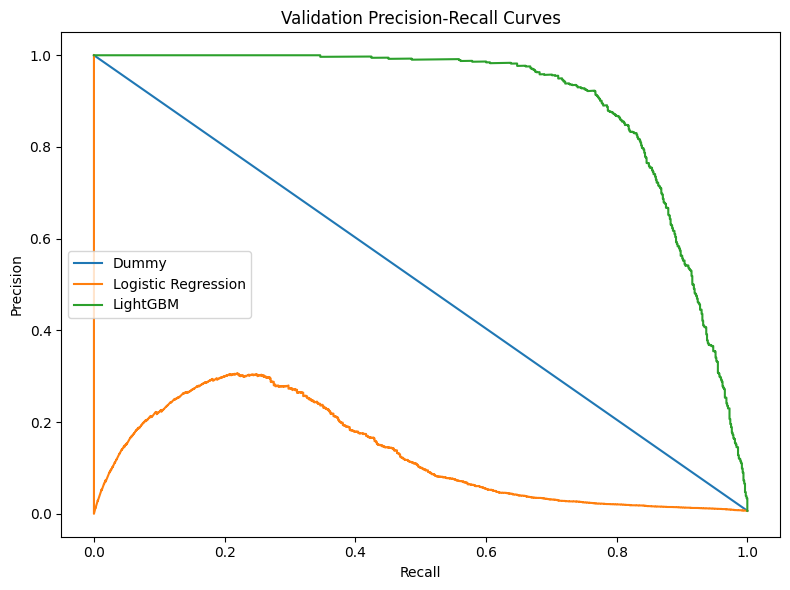

In [35]:
plt.figure(figsize=(8, 6))

for name, proba in [
    ("Dummy", dummy_proba),
    ("Logistic Regression", logistic_proba),
    ("LightGBM", lgbm_proba),
]:
    precision, recall, _ = precision_recall_curve(y_val, proba)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/baseline_pr_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 14. ROC Curves

ROC-AUC is included as a secondary ranking metric. Because the legitimate class is very large, PR-AUC receives more emphasis in this project.

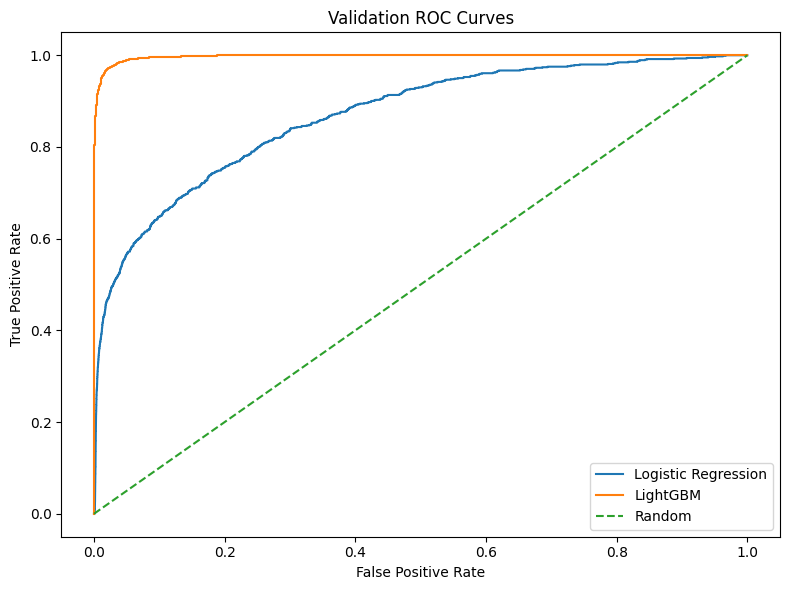

In [36]:
plt.figure(figsize=(8, 6))

for name, proba in [
    ("Logistic Regression", logistic_proba),
    ("LightGBM", lgbm_proba),
]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/baseline_roc_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 15. Save Validation Predictions

Saving development predictions makes the experiment easier to audit and reuse later. No Test predictions are created in this notebook.

In [37]:
validation_predictions = validation[
    [
        "trans_num",
        "trans_date_trans_time",
        "is_fraud",
        "amt",
    ]
].copy()

validation_predictions["dummy_probability"] = dummy_proba
validation_predictions["logistic_probability"] = logistic_proba
validation_predictions["lightgbm_probability"] = lgbm_proba

display(validation_predictions.head())

,trans_num,trans_date_trans_time,is_fraud,amt,dummy_probability,logistic_probability,lightgbm_probability
973144,4b76605c3b0d1af2eb0c4d65471a8507,2020-01-29 03:06:41,0,64.48,0.005899,0.013373,0.000020
973145,4bf9edc93a30609997e20b51463f235f,2020-01-29 03:08:10,0,105.47,0.005899,0.052909,0.000170
973146,0f954e9f95faf5c8c2fee730fd15f33c,2020-01-29 03:09:14,0,78.15,0.005899,0.573498,0.000025
973147,77ae0fef10fe571fd75ce0bceac1cd68,2020-01-29 03:09:50,0,64.90,0.005899,0.553389,0.000007
973148,8b60b26dee5e2e4a7d212b02ace322c5,2020-01-29 03:10:44,0,60.89,0.005899,0.120837,0.000031


## 16. Save Results

The notebook saves:

### Results
- `sparkov_baseline_metrics.csv`
- `sparkov_baseline_validation_predictions.csv`

### Figures
- `baseline_pr_curve.png`
- `baseline_roc_curve.png`

In [38]:
baseline_metrics.to_csv(
    "/kaggle/working/results/sparkov_baseline_metrics.csv",
    index=False
)

validation_predictions.to_csv(
    "/kaggle/working/results/sparkov_baseline_validation_predictions.csv",
    index=False
)

print("Results:", os.listdir("/kaggle/working/results"))
print("Figures:", os.listdir("/kaggle/working/figures"))

Results: ['sparkov_baseline_metrics.csv', 'sparkov_baseline_validation_predictions.csv']
Figures: ['baseline_roc_curve.png', 'baseline_pr_curve.png']


## 17. Interpretation and Limitations

This notebook answers:

> Before using customer/card history, how much fraud-detection signal is already present in the current transaction?

Interpretation guidelines:

- Higher PR-AUC means better fraud ranking under class imbalance.
- If LightGBM materially exceeds Logistic Regression, nonlinear structure is useful.
- Brier Score is preliminary because probability calibration comes later.
- Threshold 0.5 is not the final operational decision rule.

This notebook intentionally does **not** include past behavior, calibration, cost-sensitive thresholds, alert-capacity constraints, or final Test evaluation.

Sparkov is synthetic, so strong results describe simulator performance rather than real bank performance.

## Conclusion

The first leakage-safe fraud baselines have now been established using only current-transaction information.

The experiment used chronological Train / Calibration / Validation / Test periods, purge windows, Train-only preprocessing fitting, and Validation-only development evaluation.

The final Test period remained untouched.

## Next Notebook

`04_sparkov_past_only_features.ipynb`

The next step will construct card- and merchant-level behavioral features using only transactions that occurred **before** each transaction. This tests whether leakage-safe historical behavior improves fraud detection beyond the current-transaction baseline.